# ENEM — Análise e Predição da Média Ponderada (MPE), 2019 → 2023

**Projeto em grupo** · Ciência dos Dados, Engenharia de Computação — Insper (2025.2)
Julián Esteban Vargas Montaño · Carlos Lopes Mesquita Neto · Mauricio Braga Ortega Gonzalez

---

Estudo de ponta a ponta sobre os microdados do **ENEM**: da análise exploratória (2019 vs 2023)
à construção de modelos preditivos para a **Média Ponderada via ENEM (MPE)** de candidatos a
Administração/Economia. O foco não é só *rodar modelos*, mas **entender o que os dados dizem**
sobre os determinantes socioeconômicos do desempenho.

**Pergunta central:** o perfil e o desempenho dos candidatos mudaram entre 2019 e 2023, e quais
características socioeconômicas têm maior poder de prever a MPE?

A MPE para Administração/Economia segue a fórmula:

$$\text{MPE} = 0{,}75 \times (0{,}25\,\text{LC} + 0{,}40\,\text{MT} + 0{,}25\,\text{CH} + 0{,}10\,\text{CN}) + 0{,}25 \times \text{Redação}$$

## 0. Bibliotecas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")

## 1. Carregamento e limpeza

Os microdados brutos do INEP têm milhões de linhas. O tratamento é encapsulado em funções para
ser aplicado de forma idêntica a 2019 e a 2023 — em vez de duplicar o código para cada ano.

Decisões de limpeza:
- **`filtrar_validos`** mantém apenas candidatos comparáveis: não-treineiros, presentes em todas
  as provas, com redação válida e concluindo o Ensino Médio.
- **`calcular_mpe`** aplica a fórmula de ADM/ECO de forma **vetorizada** (opera na coluna inteira
  de uma vez) — em uma base de milhões de linhas, isso é ordens de magnitude mais rápido do que
  um `.apply` linha a linha.

In [8]:
COLUNAS = [
    "TP_FAIXA_ETARIA", "TP_SEXO", "TP_COR_RACA", "TP_ESCOLA", "SG_UF_PROVA",
    "Q001", "Q002", "Q006", "Q024", "Q025",
    "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO",
]


def filtrar_validos(df):
    """Mantém apenas candidatos válidos e comparáveis entre os anos."""
    return df[
        (df["IN_TREINEIRO"] == 0) &
        (df["TP_PRESENCA_CN"] == 1) & (df["TP_PRESENCA_CH"] == 1) &
        (df["TP_PRESENCA_LC"] == 1) & (df["TP_PRESENCA_MT"] == 1) &
        (df["TP_STATUS_REDACAO"] == 1) &
        (df["TP_ANO_CONCLUIU"].isin([1, 2, 3, 4]))
    ].copy()


def calcular_mpe(df):
    """MPE de Administração/Economia (vetorizado)."""
    objetivas = 0.25 * df["NU_NOTA_LC"] + 0.40 * df["NU_NOTA_MT"] \
              + 0.25 * df["NU_NOTA_CH"] + 0.10 * df["NU_NOTA_CN"]
    return 0.75 * objetivas + 0.25 * df["NU_NOTA_REDACAO"]


COLUNAS_FILTRO = ["IN_TREINEIRO", "TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC",
                  "TP_PRESENCA_MT", "TP_STATUS_REDACAO", "TP_ANO_CONCLUIU"]

def preparar(caminho, chunksize=500_000):
    """Lê o microdado bruto, filtra, seleciona colunas e calcula a MPE."""
    usar = COLUNAS + COLUNAS_FILTRO         
    pedacos = []
    for pedaco in pd.read_csv(caminho, encoding="ISO-8859-1", sep=";",
                              usecols=usar, chunksize=chunksize):
        pedacos.append(filtrar_validos(pedaco)[COLUNAS])  
    df = pd.concat(pedacos, ignore_index=True)
    df["MPE"] = calcular_mpe(df)
    return df

dados_2019 = preparar("MICRODADOS_ENEM_2019.csv")
dados_2023 = preparar("MICRODADOS_ENEM_2023.csv")
print(f"2019: {len(dados_2019):,} candidatos  |  2023: {len(dados_2023):,} candidatos")

2019: 1,134,539 candidatos  |  2023: 627,605 candidatos


## 2. Preparação das variáveis categóricas

Aqui está a maior economia em relação ao código original: em vez de repetir, para cada ano, a
conversão para categórica, a renomeação e a ordenação, definimos os mapas **uma vez** e aplicamos
a mesma função aos dois anos.

In [10]:
ROTULOS = {
    "Q001": {"A": "Nunca", "B": "Sem 4/5 ano", "C": "Sem 8/9 ano", "D": "Sem EM",
             "E": "Sem Facul", "F": "Sem Pós", "G": "Com Pós", "H": "Não Sei"},
    "Q002": {"A": "Nunca", "B": "Sem 4/5 ano", "C": "Sem 8/9 ano", "D": "Sem EM",
             "E": "Sem Facul", "F": "Sem Pós", "G": "Com Pós", "H": "Não Sei"},
    "Q006": {"A": "Nenhuma renda", "B": "Até 1.320", "C": "1.320–1.980", "D": "1.980–2.640",
             "E": "2.640–3.300", "F": "3.300–3.960", "G": "3.960–5.280", "H": "5.280–6.600",
             "I": "6.600–7.920", "J": "7.920–9.240", "K": "9.240–10.560", "L": "10.560–11.880",
             "M": "11.880–13.200", "N": "13.200–15.840", "O": "15.840–19.800",
             "P": "19.800–26.400", "Q": ">26.400"},
    "Q024": {"A": "Não", "B": "1", "C": "2", "D": "3", "E": "4 ou mais"},
    "Q025": {"A": "Não", "B": "Sim"},
    "TP_SEXO": {"M": "Masculino", "F": "Feminino"},
    "TP_COR_RACA": {0: "Não declarado", 1: "Branca", 2: "Preta", 3: "Parda",
                    4: "Amarela", 5: "Indígena"},
    "TP_ESCOLA": {1: "Não respondeu", 2: "Pública", 3: "Privada"},
}

# Variáveis ordinais: a ordem das categorias importa para a leitura dos gráficos.
ORDEM = {
    "Q001": ["Nunca", "Sem 4/5 ano", "Sem 8/9 ano", "Sem EM", "Sem Facul", "Sem Pós", "Com Pós", "Não Sei"],
    "Q002": ["Nunca", "Sem 4/5 ano", "Sem 8/9 ano", "Sem EM", "Sem Facul", "Sem Pós", "Com Pós", "Não Sei"],
    "Q006": list(ROTULOS["Q006"].values()),
    "Q024": ["Não", "1", "2", "3", "4 ou mais"],
}


def preparar_categoricas(df):
    """Aplica rótulos legíveis e ordena as variáveis ordinais (igual para qualquer ano)."""
    df = df.copy()
    for coluna, mapa in ROTULOS.items():
        df[coluna] = df[coluna].map(mapa)
    for coluna, ordem in ORDEM.items():
        df[coluna] = pd.Categorical(df[coluna], categories=ordem, ordered=True)
    return df


dados_2019 = preparar_categoricas(dados_2019)
dados_2023 = preparar_categoricas(dados_2023)

### 2.1 (opcional) Salvar a base limpa de 2023

Depois de rodar a limpeza uma vez, vale salvar a base já tratada de 2023: ela é leve, pode ser **versionada no GitHub** para tornar o modelo reproduzível e dispensa reprocessar os microdados gigantes nas próximas execuções.

In [12]:
# Rode uma vez; depois você pode commitar este CSV leve no repositório.
dados_2023.to_csv("dados_ENEM_2023.csv", index=False)
print("Base limpa salva: dados_ENEM_2023.csv")

Base limpa salva: dados_ENEM_2023.csv


## 3. Análise exploratória (2019 vs 2023)

### 3.1 Como a MPE mudou entre os anos

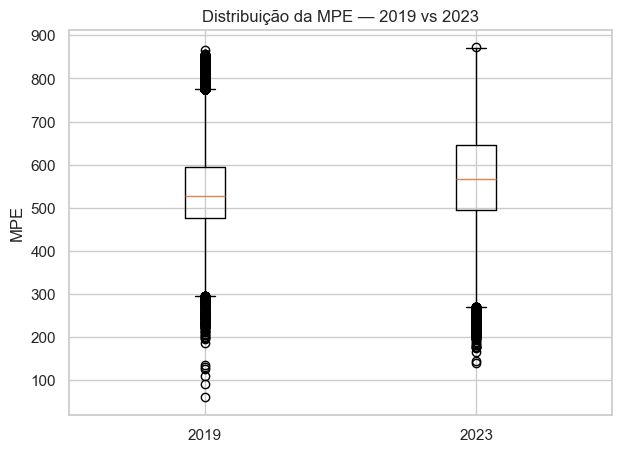

Média MPE 2019: 540.8
Média MPE 2023: 572.1


In [14]:
plt.figure(figsize=(7, 5))
plt.boxplot([dados_2019["MPE"], dados_2023["MPE"]], tick_labels=["2019", "2023"])
plt.title("Distribuição da MPE — 2019 vs 2023")
plt.ylabel("MPE")
plt.show()

print("Média MPE 2019:", round(dados_2019["MPE"].mean(), 1))
print("Média MPE 2023:", round(dados_2023["MPE"].mean(), 1))

### 3.2 Perfil socioeconômico: frequências

In [16]:
def tabela_frequencia(df, coluna):
    return (df[coluna].value_counts(normalize=True, sort=False) * 100).round(2).to_frame("%")


# Exemplo: distribuição por escolaridade do pai em 2023
tabela_frequencia(dados_2023, "Q001")

,%
Q001,
Nunca,3.04
Sem 4/5 ano,15.81
Sem 8/9 ano,13.02
Sem EM,11.20
Sem Facul,31.52
Sem Pós,9.73
Com Pós,6.77
Não Sei,8.91


### 3.3 Comparação direta 2019 × 2023

Em vez de cinco blocos de `crosstab` quase iguais, uma função e um laço sobre as variáveis de
interesse.

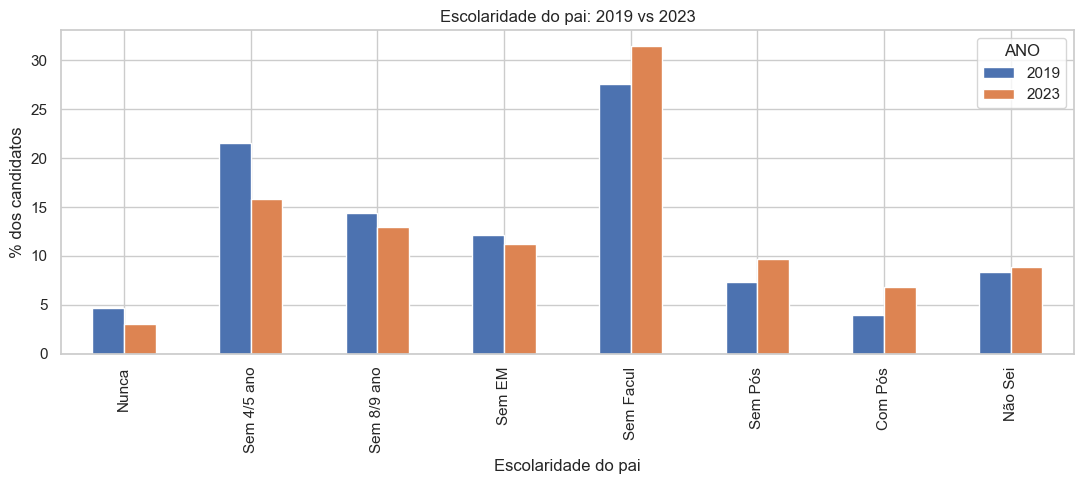

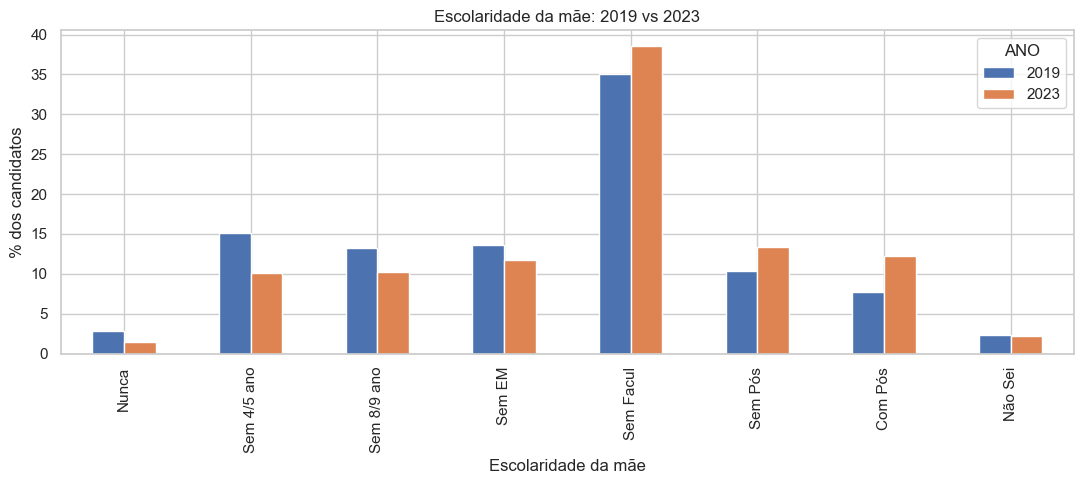

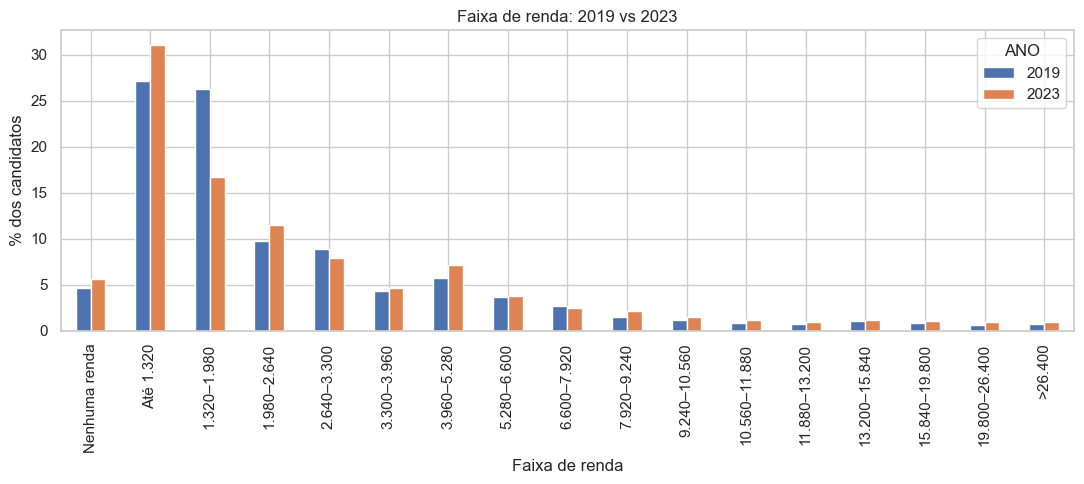

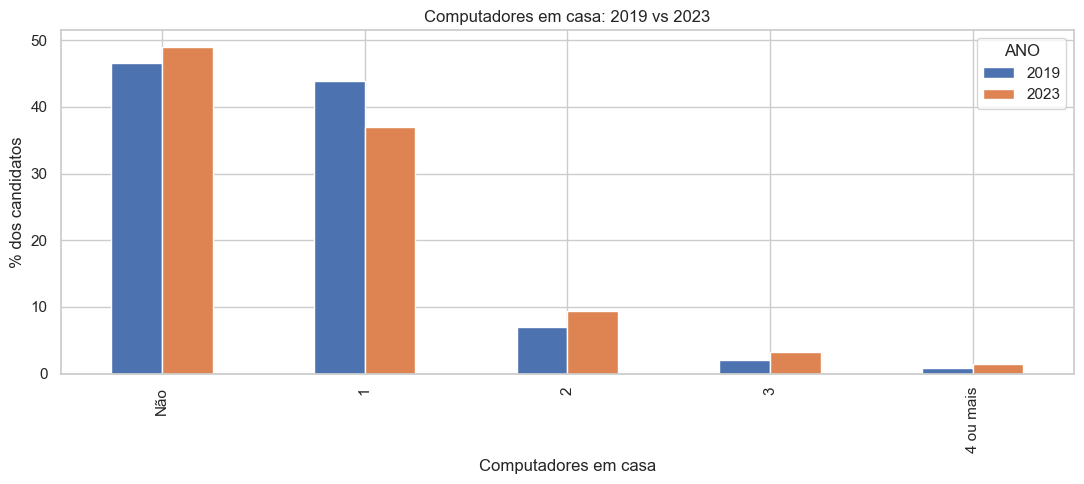

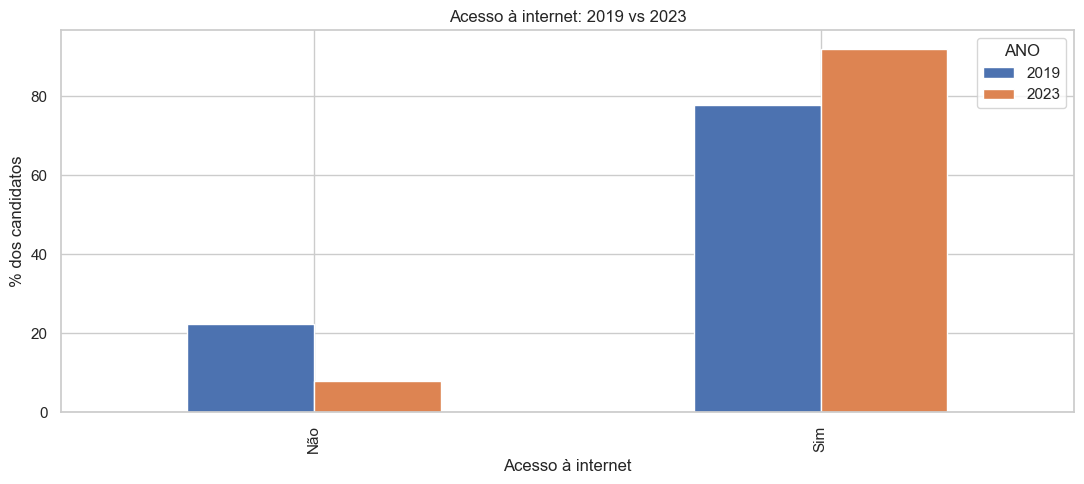

In [18]:
dados_2019["ANO"], dados_2023["ANO"] = 2019, 2023
dados_totais = pd.concat([dados_2019, dados_2023], ignore_index=True)

VARS_SOCIO = {
    "Q001": "Escolaridade do pai",
    "Q002": "Escolaridade da mãe",
    "Q006": "Faixa de renda",
    "Q024": "Computadores em casa",
    "Q025": "Acesso à internet",
}


def comparar_anos(coluna, titulo):
    tabela = pd.crosstab(dados_totais[coluna], dados_totais["ANO"], normalize="columns").round(3) * 100
    tabela.plot.bar(figsize=(11, 5))
    plt.title(f"{titulo}: 2019 vs 2023")
    plt.ylabel("% dos candidatos")
    plt.xlabel(titulo)
    plt.tight_layout()
    plt.show()
    return tabela


for coluna, titulo in VARS_SOCIO.items():
    comparar_anos(coluna, titulo)

### 3.4 Dashboard — MPE média por variável socioeconômica (2023)

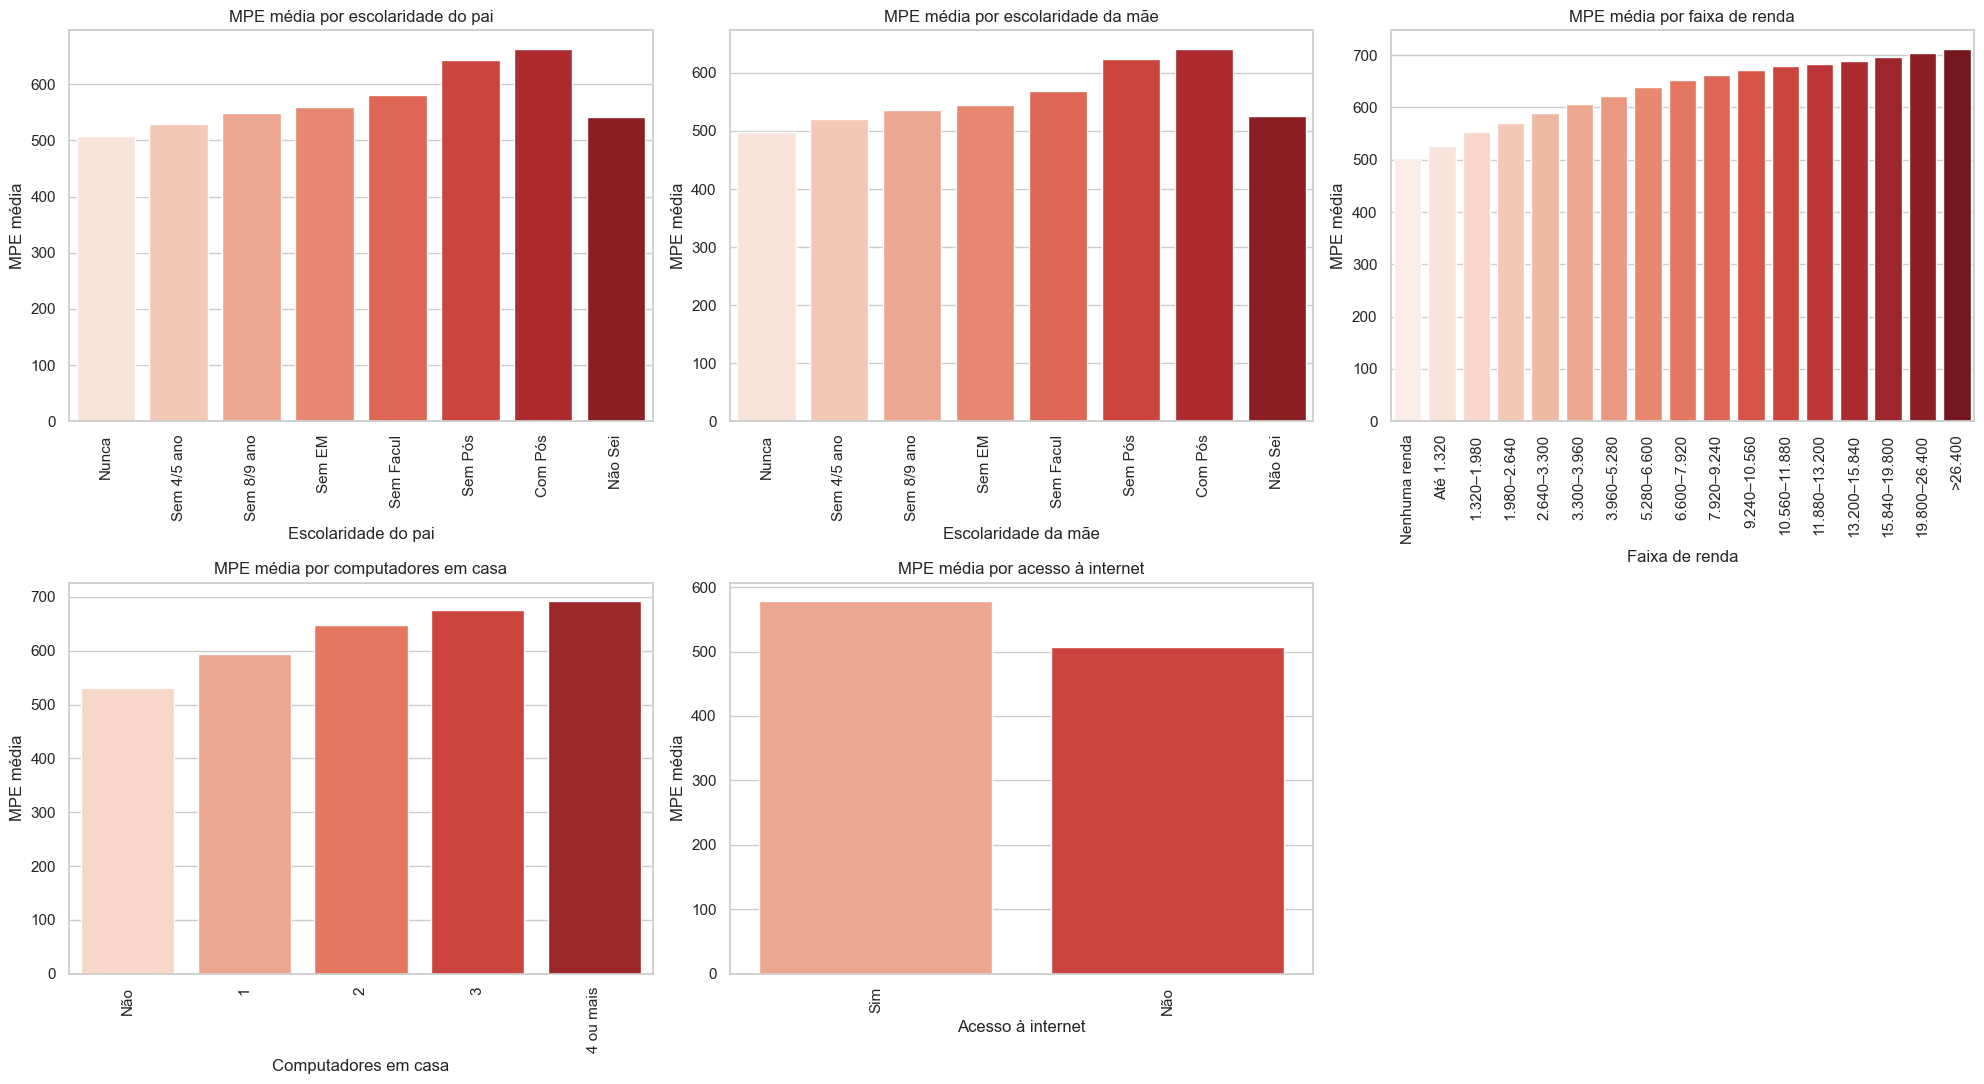

In [20]:
fig, eixos = plt.subplots(2, 3, figsize=(20, 11))
for eixo, (coluna, titulo) in zip(eixos.ravel(), VARS_SOCIO.items()):
    sns.barplot(data=dados_2023, x=coluna, y="MPE", hue=coluna,
                palette="Reds", errorbar=None, legend=False, ax=eixo)
    eixo.set_title(f"MPE média por {titulo.lower()}")
    eixo.set_xlabel(titulo)
    eixo.set_ylabel("MPE média")
    eixo.tick_params(axis="x", rotation=90)
eixos.ravel()[-1].axis("off")  # último subplot vazio
plt.tight_layout()
plt.show()

### 3.5 Conclusões da análise exploratória

- A **MPE subiu ~31 pontos** entre 2019 e 2023 — de **540,8** para **572,1** — entre os candidatos de ADM/ECO.
- Ao mesmo tempo, a **participação despencou**: os candidatos válidos caíram de **~1,13 milhão** (2019) para **~628 mil** (2023), cerca de **45% a menos** — coerente com o afastamento do ENEM no período pós-pandemia. Parte da alta na média pode refletir um público remanescente mais preparado.
- O perfil acompanha o movimento: ganho de escolaridade dos pais (no ensino básico) e maior acesso à internet. Os **mesmos determinantes** seguem relevantes nos dois anos.

> **Ressalva honesta:** com poucas variáveis socioeconômicas, o aumento de ~31 pontos é real, mas separar "o público mudou" de "o desempenho melhorou" vai além do que estes dados sustentam.

## 4. Modelo preditivo (2023)

Objetivo: prever a MPE a partir do perfil socioeconômico e descobrir **quais variáveis pesam
mais**. As notas das provas não entram como features (compõem a própria MPE).

### 4.1 Codificação e separação treino/teste

In [24]:
FEATURES_CAT = ["Q001", "Q002", "Q006", "Q024", "Q025", "TP_SEXO", "TP_ESCOLA", "TP_COR_RACA"]


def montar_X_y(df):
    X = pd.get_dummies(df[FEATURES_CAT], drop_first=True, dtype="float")
    return X, df["MPE"]


X, y = montar_X_y(dados_2023)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Features:", X.shape[1], "| Treino:", len(X_train), "| Teste:", len(X_test))

Features: 41 | Treino: 502084 | Teste: 125521


### 4.2 Regressão Linear Múltipla com seleção por p-valor

O processo manual do projeto original (remover uma variável de cada vez, recriar treino e teste,
reajustar) vira uma função: enquanto houver alguma variável com `P>|t| > 0.1`, removemos a menos
significativa e reajustamos.

In [26]:
def regress_ols(y, X):
    return sm.OLS(y, sm.add_constant(X, has_constant="add")).fit()


def selecionar_por_pvalor(y, X, limite=0.1):
    """Eliminação reversa: remove a feature menos significativa até todas terem P>|t| <= limite."""
    X = X.copy()
    while X.shape[1] > 1:
        modelo = regress_ols(y, X)
        p_valores = modelo.pvalues.drop("const", errors="ignore")
        if p_valores.max() <= limite:
            break
        X = X.drop(columns=p_valores.idxmax())
    return modelo, X


modelo_ols, X_sel = selecionar_por_pvalor(y_train, X_train)
print(f"Variáveis mantidas: {X_sel.shape[1]} de {X_train.shape[1]}")
modelo_ols.summary()

Variáveis mantidas: 39 de 41


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPE   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     6252.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:14:38   Log-Likelihood:            -2.9371e+06
No. Observations:              502084   AIC:                         5.874e+06
Df Residuals:                  502044   BIC:                         5.875e+06
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                       463.6424      0.988    469.253      0.000     461.706     465.579
Q001_Sem 4/5 ano              5.1188      0.763      6.712      0.000       3.624       6.614
Q001_Sem 8/9 ano              9.8580      0.788     12.506      0.000       8.313      11.403
Q001_Sem EM                  11.5202      0.805     14.319      0.000       9.943      13.097
Q001_Sem Facul               17.0089      0.763     22.305      0.000      15.514      18.504
Q001_Sem Pós                 35.7406      0.853     41.881      0.000      34.068      37.413
Q001_Com Pós                 32.0009      0.920     34.802      0.000      30.199      33.803
Q001_Não Sei                  5.4602      0.804      6.790      0.000       3.884       7.036
Q002_Sem 4/5 ano              9.4852      0.747     12.690      0.000       8.020      10.950
Q002_Sem 8/9 ano             13.7600      0.748     18.401      0.000      12.294      15.226
Q002_Sem EM                  15.5861      0.736     21.171      0.000      14.143      17.029
Q002_Sem Facul               24.0023      0.683     35.148      0.000      22.664      25.341
Q002_Sem Pós                 40.3791      0.750     53.871      0.000      38.910      41.848
Q002_Com Pós                 37.9274      0.771     49.214      0.000      36.417      39.438
Q006_Até 1.320               13.2967      0.552     24.096      0.000      12.215      14.378
Q006_1.320–1.980             27.0141      0.601     44.956      0.000      25.836      28.192
Q006_1.980–2.640             35.0498      0.642     54.558      0.000      33.791      36.309
Q006_2.640–3.300             44.0046      0.695     63.331      0.000      42.643      45.366
Q006_3.300–3.960             54.0896      0.789     68.597      0.000      52.544      55.635
Q006_3.960–5.280             61.8119      0.727     84.982      0.000      60.386      63.238
Q006_5.280–6.600             72.7308      0.853     85.314      0.000      71.060      74.402
Q006_6.600–7.920             79.3140      0.980     80.942      0.000      77.393      81.235
Q006_7.920–9.240             84.5411      1.033     81.823      0.000      82.516      86.566
Q006_9.240–10.560            89.5308      1.153     77.617      0.000      87.270      91.792
Q006_10.560–11.880           94.2922      1.328     70.986      0.000      91.689      96.896
Q006_11.880–13.200           96.5338      1.415     68.217      0.000      93.760      99.307
Q006_13.200–15.840           99.7613      1.350     73.897      0.000      97.115     102.407
Q006_15.840–19.800          105.0536      1.376     76.325      0.000     102.356     107.751
Q006_19.800–26.400          107.2506      1.462     73.353      0.000     104.385     110.116
Q006_>26.400                114.3170      1.460     78.308      0.000     1

### 4.3 Random Forest Regressor

A floresta é treinada **deliberadamente contida**: limitar `max_depth` e exigir um mínimo de
amostras por folha (`min_samples_leaf`) acelera muito o treino — essencial porque a validação
cruzada vai treinar a floresta 10 vezes — e, mais importante, **reduz o overfitting** que tínhamos
observado (treino bem acima do teste). Ou seja, é uma melhoria real, não só um atalho de velocidade.

In [28]:
rf = RandomForestRegressor(
    n_estimators=100,      # 100 árvores já bastam; 200 dobra o tempo por ganho marginal
    max_depth=20,          # limita a profundidade -> muito mais rápido E menos overfitting
    min_samples_leaf=50,   # evita folhas minúsculas (ruído); acelera o treino
    random_state=42,
    n_jobs=-1,             # usa todos os núcleos da máquina
)
rf.fit(X_train, y_train)

importancias = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("10 variáveis mais importantes:")
print(importancias.head(10))

10 variáveis mais importantes:
Q006_Até 1.320        0.272491
TP_COR_RACA_Branca    0.163239
Q024_1                0.077513
Q001_Sem Pós          0.067317
Q001_Com Pós          0.058966
Q024_2                0.051058
Q006_1.320–1.980      0.045077
Q024_3                0.037547
Q006_1.980–2.640      0.026826
Q002_Sem Pós          0.023477
dtype: float64


### 4.4 Avaliação e comparação

Uma única função de métricas (R², RMSE, MAE) usada para treino e teste dos dois modelos — em vez
de repetir o bloco de avaliação quatro vezes.

In [30]:
def avaliar(y_true, y_pred):
    return {
        "R² (%)": r2_score(y_true, y_pred) * 100,
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


X_sel_test = X_test[X_sel.columns]
comparacao = pd.DataFrame({
    "OLS (treino)": avaliar(y_train, modelo_ols.predict(sm.add_constant(X_sel, has_constant="add"))),
    "OLS (teste)":  avaliar(y_test,  modelo_ols.predict(sm.add_constant(X_sel_test, has_constant="add"))),
    "RF (treino)":  avaliar(y_train, rf.predict(X_train)),
    "RF (teste)":   avaliar(y_test,  rf.predict(X_test)),
}).round(2).T
comparacao

,R² (%),RMSE,MAE
OLS (treino),32.69,84.01,67.47
OLS (teste),32.67,83.89,67.38
RF (treino),33.05,83.78,67.28
RF (teste),32.14,84.22,67.60


### 4.5 Validação cruzada (k-fold, k=10)

Os dois blocos de validação cruzada quase idênticos do original viram **uma** função que recebe
"como treinar e prever" e roda o mesmo procedimento para qualquer modelo.

In [52]:
def validacao_cruzada(treinar_prever, X, y, k=10, semente=42):
    kf = KFold(n_splits=k, shuffle=True, random_state=semente)
    linhas = [avaliar(y.iloc[va], treinar_prever(X.iloc[tr], y.iloc[tr], X.iloc[va]))
              for tr, va in kf.split(X)]
    resultado = pd.DataFrame(linhas)
    resultado.index = range(1, k + 1)
    resultado.index.name = "Fold"
    resumo = resultado.agg(["mean", "std"])
    return pd.concat([resultado, resumo])


def prever_ols(X_tr, y_tr, X_va):
    m = regress_ols(y_tr, X_tr)
    return m.predict(sm.add_constant(X_va, has_constant="add"))


def prever_rf(X_tr, y_tr, X_va):
    # MESMOS parâmetros leves da seção 4.3 — sem isso, a CV treina a floresta 10x e trava
    m = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_leaf=50,
                              random_state=42, n_jobs=-1).fit(X_tr, y_tr)
    return m.predict(X_va)


print("Regressão Linear Múltipla:")
display(validacao_cruzada(prever_ols, X_sel, y_train).round(4))
print("\nRandom Forest:")
display(validacao_cruzada(prever_rf, X_train, y_train, k=5).round(4))

Regressão Linear Múltipla:


,R² (%),RMSE,MAE
1,32.6932,84.2112,67.6192
2,32.2477,84.5099,67.8395
3,32.5933,83.9863,67.4442
4,33.0018,83.9926,67.3758
5,32.8382,84.3171,67.7291
6,32.6766,83.8227,67.3318
7,32.7956,83.8689,67.3293
8,32.1001,83.8439,67.4354
9,32.8667,83.7148,67.3726
10,32.9760,83.8691,67.2810



Random Forest:


,R² (%),RMSE,MAE
1,31.8943,84.7200,67.9704
2,32.2641,84.3234,67.6746
3,32.1060,84.4779,67.8343
4,31.8972,84.1987,67.6306
5,32.3027,84.1782,67.6315
mean,32.0929,84.3796,67.7483
std,0.1944,0.2247,0.1497


### 4.6 Resultados e interpretação

Números reais desta execução (tabela da seção 4.4 + validação cruzada):

| Modelo | R² (teste) | R² (treino) | Leitura |
|---|---|---|---|
| **Regressão Linear Múltipla** | **32,7%** | 32,7% | Generalização quase perfeita (treino ≈ teste) |
| Random Forest (contido) | 32,1% | 33,0% | Vão treino–teste de ~1 ponto: overfitting mínimo |

Na validação cruzada os dois ficaram estáveis: OLS **32,7% ± 0,30%** e RF **32,1% ± 0,19%**. Os modelos praticamente **empatam**, com leve vantagem da regressão linear — o que reforça que a relação entre perfil e MPE é **predominantemente linear**: a flexibilidade extra da floresta não trouxe ganho real, e a versão contida ainda eliminou o overfitting que havia antes.

**As variáveis que mais pesam (importância na floresta):** de longe, estar na **menor faixa de renda** (`Q006_Até 1.320`); em seguida, ser **branco** (`TP_COR_RACA_Branca`) e a **escolaridade dos pais** (`Q001`). O **acesso a computador** (`Q024`) aparece, mas em segundo plano. Ou seja: os determinantes mais fortes da MPE são **renda e raça** — um retrato direto da desigualdade socioeconômica que o ENEM reflete.

**Por que ~33% não é um modelo fraco, e sim a resposta honesta:** o perfil socioeconômico explica cerca de **um terço** da variação da MPE (R² ≈ 0,33). Os outros dois terços vivem em fatores que estes dados não enxergam (esforço individual, qualidade da escola, etc.). Um modelo que previsse a nota a 90% só com renda e raça é que seria suspeito.

## 5. Conclusão

O projeto foi da exploração (2019 vs 2023) à predição da MPE de ADM/ECO. Quatro achados:

1. A MPE **subiu ~31 pontos** (540,8 → 572,1), enquanto a **participação caiu ~45%** (1,13 mi → 628 mil candidatos válidos).
2. Os preditores mais fortes da MPE são **renda e raça**, seguidos da escolaridade dos pais; o acesso a computador contribui em segundo plano.
3. Regressão linear e Random Forest praticamente **empatam** (~32–33% de R²), indicando relação **predominantemente linear**.
4. O perfil socioeconômico explica **~1/3** da variação da MPE: substancial, mas longe de determinístico.

**Aplicações:** orientação vocacional, políticas de redução de desigualdade (renda e acesso) e monitoramento contínuo da relação entre contexto socioeconômico e desempenho.

**Limitações e próximos passos:** apenas features socioeconômicas; testar variáveis contínuas e regressões regularizadas (Ridge/Lasso); reaplicar em mais edições para ver se as variáveis importantes mudam ao longo do tempo.

## Referências

- INEP. *Microdados do ENEM 2019 e 2023.* Disponível no portal de dados abertos do INEP.
- McKinney, W. *pandas* · Pedregosa et al. *scikit-learn* · Seabold & Perktold, *statsmodels*.
- Rocha, A. M.; de F.; Gondim, A. *Perfil e desempenho dos participantes do ENEM 2019–2022 sob a
  perspectiva da COVID-19.* Revista Caribeña de Ciencias Sociales, 2023.
- Instituto Unibanco; Brasil Escola — reportagens sobre participação e desigualdade no ENEM.